<a href="https://colab.research.google.com/github/theyuvrajtayal21-design/100-day-bootcamp/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv('/content/aiml_student_placement.csv')
display(df.head())

,student_id,cgpa,attendance_pct,aptitude_score,coding_score,communication_score,internship_completed,backlogs,placed
0,AIML1001,7.50,84.2,45.2,61.3,61.8,No,0,0
1,AIML1002,6.16,71.1,57.7,70.0,81.7,No,0,1
2,AIML1003,7.95,93.3,71.3,56.5,71.9,No,0,0
3,AIML1004,8.14,70.5,63.5,54.6,58.2,No,1,0
4,AIML1005,5.25,70.4,55.2,63.7,55.9,No,1,0


In [ ]:
display(df.head(10))
print("Dataset shape", df.shape)
df.info()
display(df.describe(include = "all").T)

,student_id,cgpa,attendance_pct,aptitude_score,coding_score,communication_score,internship_completed,backlogs,placed
0,AIML1001,7.50,84.2,45.2,61.3,61.8,No,0,0
1,AIML1002,6.16,71.1,57.7,70.0,81.7,No,0,1
2,AIML1003,7.95,93.3,71.3,56.5,71.9,No,0,0
3,AIML1004,8.14,70.5,63.5,54.6,58.2,No,1,0
4,AIML1005,5.25,70.4,55.2,63.7,55.9,No,1,0
5,AIML1006,5.90,84.5,54.9,27.4,44.9,Yes,0,0
6,AIML1007,7.33,87.2,54.3,70.6,72.1,No,0,1
7,AIML1008,6.88,83.4,51.8,62.0,63.0,No,0,0
8,AIML1009,7.18,57.8,99.2,62.7,34.8,Yes,0,0
9,AIML1010,6.35,84.5,69.5,79.3,60.5,Yes,1,0


Dataset shape (602, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602 entries, 0 to 601
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            602 non-null    object 
 1   cgpa                  599 non-null    float64
 2   attendance_pct        600 non-null    float64
 3   aptitude_score        602 non-null    float64
 4   coding_score          600 non-null    float64
 5   communication_score   602 non-null    float64
 6   internship_completed  602 non-null    object 
 7   backlogs              602 non-null    int64  
 8   placed                602 non-null    int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 42.5+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,602,600,AIML1081,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cgpa,599.0,NaN,NaN,NaN,7.181386,0.983965,4.5,6.505,7.18,7.785,11.2
attendance_pct,600.0,NaN,NaN,NaN,77.703,11.763599,35.0,70.375,78.1,85.425,112.0
aptitude_score,602.0,NaN,NaN,NaN,63.810299,15.522783,20.7,54.1,64.25,74.075,100.0
coding_score,600.0,NaN,NaN,NaN,60.871,17.900093,-8.0,48.775,62.45,72.925,100.0
communication_score,602.0,NaN,NaN,NaN,68.61412,14.189228,27.9,58.725,68.15,78.975,100.0
internship_completed,602,4,Yes,348,NaN,NaN,NaN,NaN,NaN,NaN,NaN
backlogs,602.0,NaN,NaN,NaN,0.450166,0.764222,0.0,0.0,0.0,1.0,3.0
placed,602.0,NaN,NaN,NaN,0.413621,0.492892,0.0,0.0,0.0,1.0,1.0


In [ ]:
clean_df = df.copy()
duplicate_count  = clean_df.duplicated().sum()
print("Exact duplicate rows ", duplicate_count)
clean_df = clean_df.drop_duplicates()
clean_df["internship_completed"] = (clean_df["internship_completed"] == "Yes").astype(int)
display(clean_df.head())

Exact duplicate rows  2


,student_id,cgpa,attendance_pct,aptitude_score,coding_score,communication_score,internship_completed,backlogs,placed
0,AIML1001,7.50,84.2,45.2,61.3,61.8,0,0,0
1,AIML1002,6.16,71.1,57.7,70.0,81.7,0,0,1
2,AIML1003,7.95,93.3,71.3,56.5,71.9,0,0,0
3,AIML1004,8.14,70.5,63.5,54.6,58.2,0,1,0
4,AIML1005,5.25,70.4,55.2,63.7,55.9,0,1,0


### Handle Missing Values

From the `df.info()` output, we observed missing values in `cgpa`, `attendance_pct`, and `coding_score`. I will impute these missing numerical values with the mean of their respective columns.

In [ ]:
clean_df['cgpa'] = clean_df['cgpa'].fillna(clean_df['cgpa'].mean())
clean_df['attendance_pct'] = clean_df['attendance_pct'].fillna(clean_df['attendance_pct'].mean())
clean_df['coding_score'] = clean_df['coding_score'].fillna(clean_df['coding_score'].mean())

print("Missing values after imputation:")
display(clean_df.isnull().sum())

Missing values after imputation:


,0
student_id,0
cgpa,0
attendance_pct,0
aptitude_score,0
coding_score,0
communication_score,0
internship_completed,0
backlogs,0
placed,0


In [ ]:
X = clean_df.drop(['student_id', 'placed'], axis=1)
y = clean_df['placed']

print("Features (X) head:")
display(X.head())
print("Target (y) head:")
display(y.head())

Features (X) head:


,cgpa,attendance_pct,aptitude_score,coding_score,communication_score,internship_completed,backlogs
0,7.50,84.2,45.2,61.3,61.8,0,0
1,6.16,71.1,57.7,70.0,81.7,0,0
2,7.95,93.3,71.3,56.5,71.9,0,0
3,8.14,70.5,63.5,54.6,58.2,0,1
4,5.25,70.4,55.2,63.7,55.9,0,1


Target (y) head:


,placed
0,0
1,1
2,0
3,0
4,0


In [ ]:
import numpy as np

valid_ranges = {
    'cgpa': (0.0, 10.0),
    'attendance_pct': (0.0, 100.0),
    'coding_score': (0.0, 100.0)
}

for column, (min_val, max_val) in valid_ranges.items():
    invalid_mask = (clean_df[column] < min_val) | (clean_df[column] > max_val)
    if invalid_mask.any():
        print(f"Found {invalid_mask.sum()} invalid values in '{column}':")
        display(clean_df[invalid_mask])
        # Replace invalid values with NaN
        clean_df.loc[invalid_mask, column] = np.nan
        # Re-impute with the mean of the valid values
        clean_df[column] = clean_df[column].fillna(clean_df[column].mean())

print("Missing values after handling outliers and re-imputation:")
display(clean_df.isnull().sum())
print("Descriptive statistics after handling outliers:")
display(clean_df.describe())

Missing values after handling outliers and re-imputation:


,0
student_id,0
cgpa,0
attendance_pct,0
aptitude_score,0
coding_score,0
communication_score,0
internship_completed,0
backlogs,0
placed,0


Descriptive statistics after handling outliers:


,cgpa,attendance_pct,aptitude_score,coding_score,communication_score,internship_completed,backlogs,placed
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,7.174430,77.639053,63.763333,60.940151,68.547333,0.578333,0.451667,0.411667
std,0.969018,11.669706,15.524587,17.659687,14.162848,0.494238,0.765053,0.492546
min,4.500000,35.000000,20.700000,6.900000,27.900000,0.000000,0.000000,0.000000
25%,6.507500,70.375000,54.100000,48.950000,58.700000,0.000000,0.000000,0.000000
50%,7.180570,78.100000,63.950000,62.300000,68.100000,1.000000,0.000000,0.000000
75%,7.780000,85.400000,74.025000,72.900000,78.825000,1.000000,1.000000,1.000000
max,10.000000,100.000000,100.000000,100.000000,100.000000,1.000000,3.000000,1.000000


### Prepare Data for Modeling (Re-running after Outlier Handling)

Since the `clean_df` has been further processed to handle outliers, I will re-extract the features (input variables) into `X` and the target variable (`placed`) into `y`. The `student_id` column will continue to be dropped.

In [ ]:
X = clean_df.drop(['student_id', 'placed'], axis=1)
y = clean_df['placed']

print("Features (X) head after cleaning:")
display(X.head())
print("Target (y) head:")
display(y.head())

Features (X) head after cleaning:


,cgpa,attendance_pct,aptitude_score,coding_score,communication_score,internship_completed,backlogs
0,7.50,84.2,45.2,61.3,61.8,0,0
1,6.16,71.1,57.7,70.0,81.7,0,0
2,7.95,93.3,71.3,56.5,71.9,0,0
3,8.14,70.5,63.5,54.6,58.2,0,1
4,5.25,70.4,55.2,63.7,55.9,0,1


Target (y) head:


,placed
0,0
1,1
2,0
3,0
4,0


### Feature Scaling (Re-running)

To ensure that all features contribute equally to the model's performance, I will scale the numerical features in `X` using `StandardScaler`. This transforms the data such that it has a mean of 0 and a standard deviation of 1.

In [ ]:
scaler = StandardScaler()

numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()

X_scaled = X.copy()
X_scaled[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print("Scaled Features (X_scaled) head:")
display(X_scaled.head())
print("Descriptive statistics of scaled features:")
display(X_scaled.describe())

NameError: name 'StandardScaler' is not defined

### Split Data into Training and Testing Sets (Re-running)

To evaluate the model's performance on unseen data, I will split the `X_scaled` (features) and `y` (target) into training and testing sets using `train_test_split`. A test size of 20% and a `random_state` will ensure reproducibility.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

NameError: name 'train_test_split' is not defined

### Train K-Nearest Neighbors (KNN) Classifier (Re-running)

I will now train a K-Nearest Neighbors classifier on the scaled training data (`X_train`, `y_train`). I'll use a common value for `n_neighbors`, such as 5, as a starting point.

In [ ]:
# Initialize the KNN classifier with n_neighbors = 5
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model using the training data
knn_model.fit(X_train, y_train)

print("KNN model trained successfully.")

NameError: name 'KNeighborsClassifier' is not defined

### Evaluate Model Performance (Re-running)

Now, I will make predictions on the test set and evaluate the model's performance using classification metrics such as F1-score and accuracy score, along with a confusion matrix for detailed insights.

In [ ]:
# Make predictions on the test set
y_pred = knn_model.predict(X_test)

# Evaluate the model
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"F1 Score: {f1:.4f}")
print(f"Accuracy Score: {accuracy:.4f}")
print("Confusion Matrix:")
display(pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

NameError: name 'knn_model' is not defined

In [ ]:
numerical_features = ['cgpa', 'attendance_pct', 'coding_score']
for column in numerical_features:
  clean_df[column] = (clean_df[column].fillna(clean_df[column].median()))
  clean_df

In [ ]:
clean_df["internship_completed"] = (clean_df["internship_completed"].fillna(clean_df['internship_completed'].mode()[0])) # .mode() returns a Series, so select the first mode
print("Remaining missing values:")
display(clean_df.isnull().sum())

print("internship catagories")
display(clean_df["internship_completed"].value_counts())

Remaining missing values:


,0
student_id,0
cgpa,0
attendance_pct,0
aptitude_score,0
coding_score,0
communication_score,0
internship_completed,0
backlogs,0
placed,0


internship catagories


,count
internship_completed,
1,347
0,253


In [ ]:
target_counts = clean_df['placed'].value_counts()
target_percentage = (
    clean_df["placed"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .astype(str)
    + "%"
)
targert_report = pd.DataFrame({"counts": target_counts, "percentage": target_percentage})
display(targert_report)

,counts,percentage
placed,,
0,353,58.83%
1,247,41.17%


In [ ]:
target_counts.plot(
    kind = "bar",
    title = "PLacement Target "
)
plt.xlabel("Placed")
plt.ylabel("Count")
plt.show()



NameError: name 'target_counts' is not defined

In [ ]:
group_summary = clean_df.groupby("placed")[
    numerical_features
].mean().round(2)

display(group_summary)

,cgpa,attendance_pct,coding_score
placed,,,
0,6.94,76.92,57.33
1,7.51,78.66,66.10


In [ ]:
from scipy.spatial.distance import correlation
correlation_columns = numerical_features + ["placed"]
correlation_matrix = clean_df[correlation_columns].corr()
display(correlation_matrix)

,cgpa,attendance_pct,coding_score,placed
cgpa,1.000000,-0.083488,-0.028407,0.292405
attendance_pct,-0.083488,1.000000,-0.001604,0.073322
coding_score,-0.028407,-0.001604,1.000000,0.244405
placed,0.292405,0.073322,0.244405,1.000000


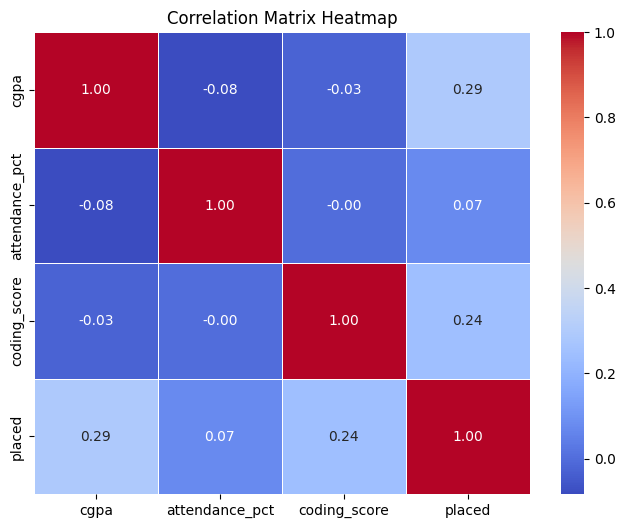

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [ ]:
data = df.copy()

# Correctly map string values to integers
data["internship_completed"] = data["internship_completed"].map({
    "Yes": 1,
    "No": 0
})

X = data[[
    "cgpa",
    "attendance_pct",
    "aptitude_score",
    "internship_completed"
    ]]

y = data["placed"]

print("Feature columns (X) head:")
display(X.head())
print("Target column (y) head:")
display(y.head())

Feature columns (X) head:


,cgpa,attendance_pct,aptitude_score,internship_completed
0,7.06,76.1,66.4,1
1,7.53,75.1,65.0,1
2,6.17,69.6,63.4,0
3,5.66,67.3,93.3,0
4,8.60,100.0,64.8,1


Target column (y) head:


,placed
0,0
1,1
2,0
3,0
4,1


In [ ]:
import pandas as pd
df = pd.read_csv("/content/student_placement_classification.csv")
display(df.head())

,student_id,cgpa,attendance_pct,aptitude_score,coding_score,internship_completed,placed
0,STU001,7.06,76.1,66.4,76.2,Yes,0
1,STU002,7.53,75.1,65.0,66.9,Yes,1
2,STU003,6.17,69.6,63.4,40.7,No,0
3,STU004,5.66,67.3,93.3,66.2,No,0
4,STU005,8.60,100.0,64.8,71.0,Yes,1


In [ ]:
from sklearn.model_selection import train_test_split

# Splitting the data - Corrected order: X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Defining the logistic regression pipeline
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=1000))
])

# Training the model
logistic_model.fit(X_train, y_train)

# Making predictions
logistic_prediction = logistic_model.predict(X_test)

print("Logistic Regression model trained and predictions made successfully.")

Logistic Regression model trained and predictions made successfully.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,ConfusionMatrixDisplay,classification_report
import matplotlib.pyplot as plt

# Evaluating the model

# Using the correct variable 'logistic_prediction' which was defined in the previous cell
accuracy = accuracy_score(y_test, logistic_prediction)
precision = precision_score(y_test, logistic_prediction)
recall = recall_score(y_test, logistic_prediction)
f1 = f1_score(y_test, logistic_prediction)

print("Accuracy: ", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:   ", round(recall, 3))
print("F1 Score: ", round(f1, 3))

Accuracy:  0.833
Precision: 0.824
Recall:    0.875
F1 Score:  0.848


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

knn_prediction = knn_model.predict(X_test)
print("KNN model trained and predictions made successfully.")

KNN model trained and predictions made successfully.


In [ ]:
# Evaluate KNN performance
knn_accuracy = accuracy_score(y_test, knn_prediction)
knn_precision = precision_score(y_test, knn_prediction)
knn_recall = recall_score(y_test, knn_prediction)
knn_f1 = f1_score(y_test, knn_prediction)

print("--- KNN Model Performance ---")
print(f"Accuracy:  {knn_accuracy:.3f}")
print(f"Precision: {knn_precision:.3f}")
print(f"Recall:    {knn_recall:.3f}")
print(f"F1 Score:  {knn_f1:.3f}")

--- KNN Model Performance ---
Accuracy:  0.800
Precision: 0.812
Recall:    0.812
F1 Score:  0.812


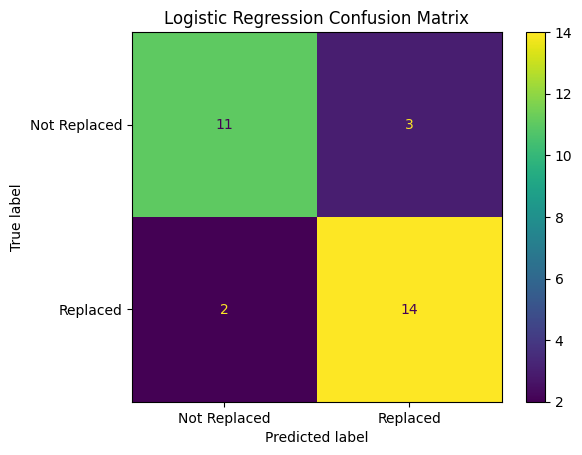

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, logistic_prediction, display_labels=["Not placed", "placed"])
plt.title("Logistic Regression Confusion Matrix")
plt.show()


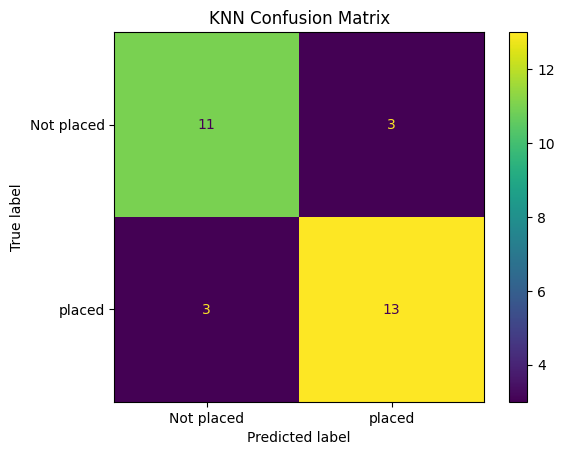

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, knn_prediction, display_labels=["Not placed", "placed"])
plt.title("KNN Confusion Matrix")
plt.show()